# Assumptions of Linear Regression

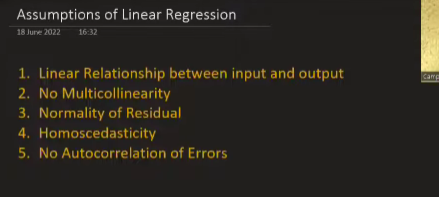

- In this lesson we will discuss the assumptions of linear regression, and using code we will see how to check if these assumptions are met.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [4]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

In [5]:
X

array([[-5.70562824e-01,  1.42034231e+00,  4.95580395e-01],
       [-9.90562704e-01,  5.56964528e-01,  1.04506399e+00],
       [-6.74727510e-01,  1.50616865e-01,  1.77464503e+00],
       [ 3.88250414e-01, -3.87127181e-01, -1.10229155e-01],
       [ 1.16788229e+00, -2.41044701e-02,  1.45063214e-01],
       [-8.89888979e-01, -1.58094538e+00, -4.22792727e-01],
       [-2.68510868e+00,  1.84207947e-02,  1.72266920e+00],
       [ 6.63187770e-01,  1.85267835e-01, -1.88342383e+00],
       [ 3.19196176e-01, -2.98397020e+00, -1.51521566e+00],
       [-3.48368316e-01, -1.81101917e+00,  7.46891531e-01],
       [-6.37134863e-01, -5.39574612e-01, -4.08345242e-01],
       [ 1.11594518e+00, -3.03033672e-02, -3.19590141e-01],
       [-6.89599657e-01, -3.57440729e-01, -5.41503716e-01],
       [ 2.07087853e+00,  1.06979836e+00,  5.93588115e-01],
       [-7.12849796e-01, -1.50891712e+00, -2.52815988e-01],
       [ 8.87925723e-01, -8.23886105e-01,  4.36232115e-01],
       [-2.94033248e-01, -6.87859510e-01

In [6]:
X.shape, y.shape

((200, 3), (200,))

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
# Residual
y_pred = model.predict(X_test)
residual = y_test - y_pred

## 1. Linear Relationship

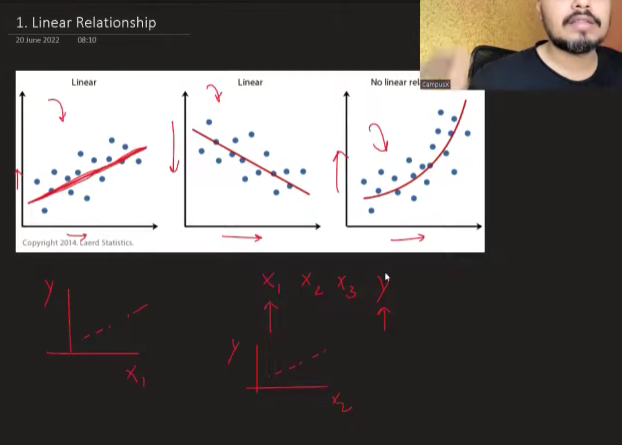

- Each input feature should have a linear relationship with the target variable. This can be checked using scatter plots or correlation coefficients.

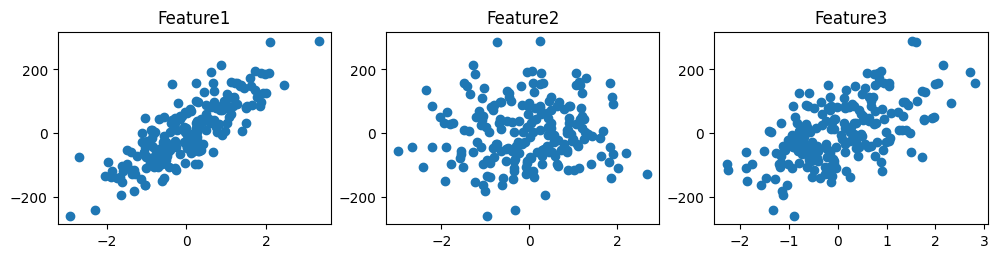

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

## 2. Multicollinearity

- Humare system mei koi vhi multi-collinearity nahi honi chahiye. Matlab, input features ke beech mein high correlation nahi honi chahiye. Agar do ya zyada features highly correlated hain, toh unmein se ek ko model se hata dena chahiye.

## <span style="color:orange">Why is Multicollinearity a Problem?</span>

- $\beta_1$ tells how much change tere will be in the target variable for a unit change in $X_1$, keeping all other features constant. But if $X_1$ and $X_2$ are highly correlated (then the assumption of other features being constant is violated), then it's hard to say how much of the change in the target variable is due to $X_1$ and how much is due to $X_2$. This makes the coefficients unstable and unreliable.

- <span style="color:orange">More real life example: </span>
    Suppose for an project 2 scientists come from 2 different backgrounds. One is a physicist and the other is a mathematician. So, their contribution for the project will be very clearly defined. But if both of them are physicists, then it will be hard to say who contributed what for the project. This is the problem of multicollinearity in linear regression.

### How to check for Multicollinearity in the Data?

- To find wether there is multicollinearity in the system or not, we can use the Variance Inflation Factor (VIF). VIF measures how much the variance of a regression coefficient is inflated due to multicollinearity.

- If result for each feature is 1, then there is no multicollinearity. If the value is between 1 and 5, then there is moderate multicollinearity. If the value is greater than 5 or 10, then there is high multicollinearity.


In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [12]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


- See above , the VIF for each feature is nearly one, which indicates that there is no multicollinearity in the system.

- If the value would be near 5 for any feature, then hum uss column ko hata dete as wo feature jo kaam kr raha hai wo baaki features milke kr de rhe hai 

<Axes: >

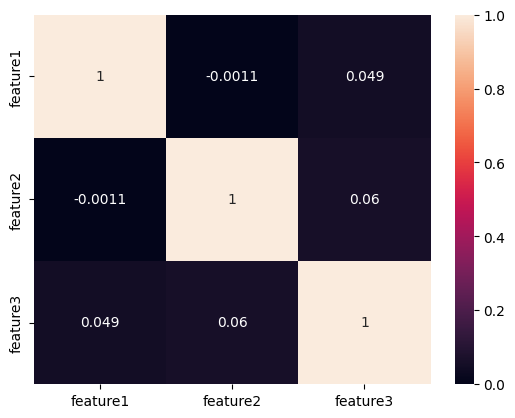

In [13]:
# Another Technique
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

## 3. Normality of Residual

- Residuals hum errors ko bol skte hai
- residual = actual value - predicted value (We did in the code as well initially, see 9th code cell from the top)

### <span style="color:orange">Residuals should be normally distributed</span>

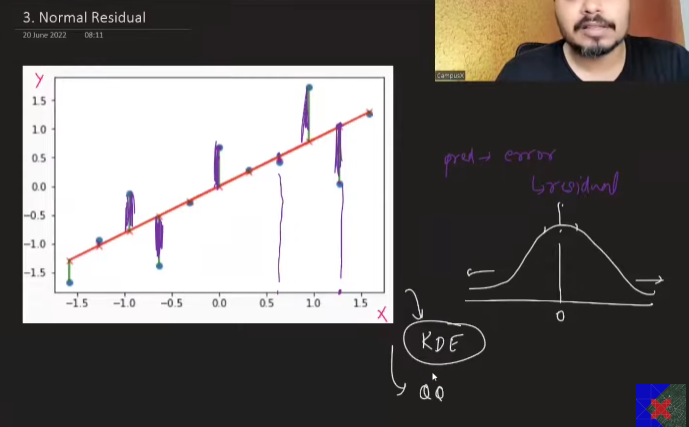

- You can check the normality of residuals using a KDE plot or a Q-Q plot. 

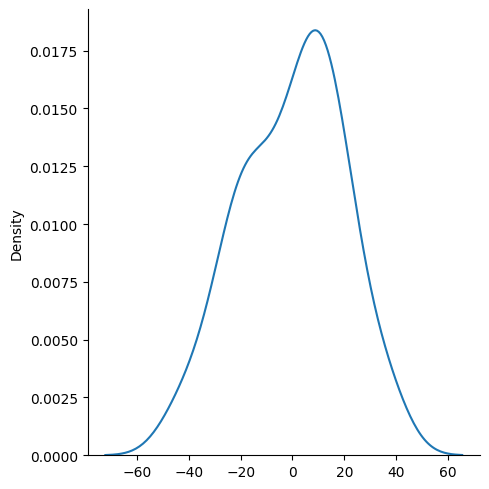

In [14]:
sns.displot(residual,kind='kde')

- Almost normal just there is aslight bump

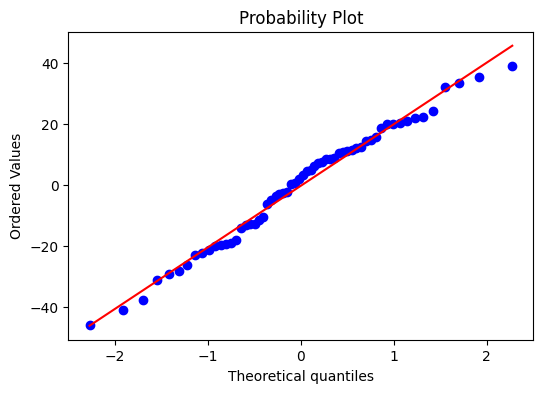

In [15]:
# QQ Plot

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

## 4. Homoscedasticity

- When we plot the residuals against the predicted values, the spread should be same. <span style="color:orange">(The scatter in the scatter plot should be uniform across the length of predicted values)</span>
- If spread is not same, then it is called heteroscedasticity, which is a problem for linear regression.

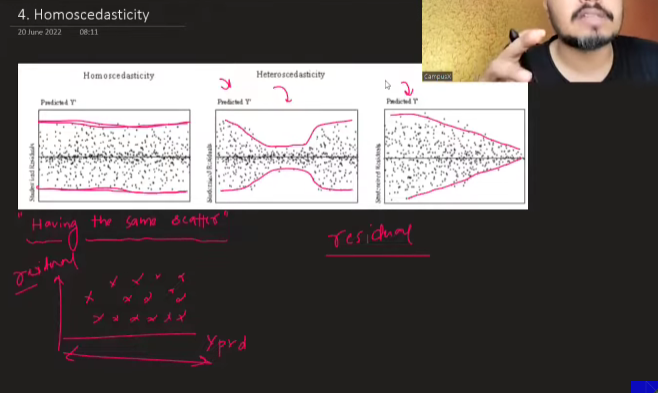

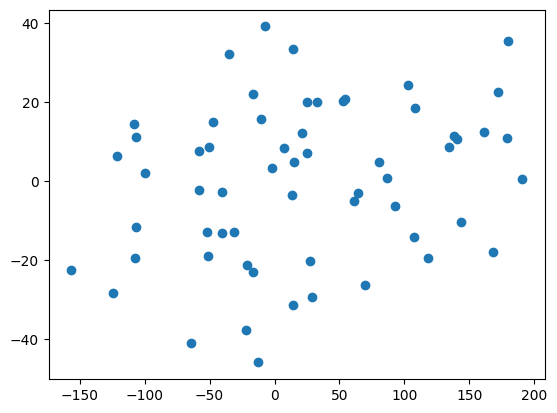

In [16]:
plt.scatter(y_pred,residual)

## 5. NO Autocorrelation of Residuals

- Agar aap aapke residual ko plot kr rhe ho to koi pattern nahi dikhna chahiye. Agar pattern dikh raha hai, to iska matlab hai ki residuals ke beech mein correlation hai, jo ki linear regression ke assumptions ke khilaf hai.

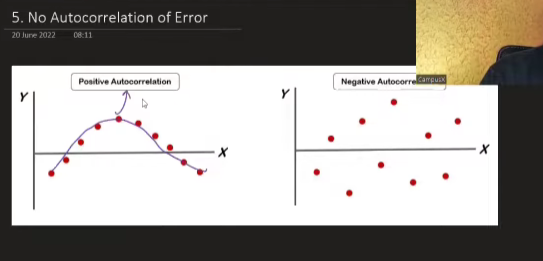

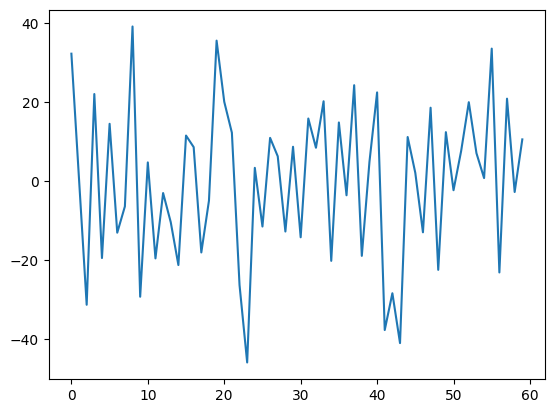

In [ ]:
plt.plot(residual) 

- Zig-zag pattern dikh raha hai, to iska matlab hai ki residuals ke beech mein correlation nahi hai

plt.plot(residual) =
👉 residuals plotted against their index (order in dataset), not against X or predictions.